In [1]:
#Imports, Mappings & Device Setup

import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

# Using GPU if available; essential for training Recurrent Neural Networks (RNNs) in a reasonable timeframe.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

# Master list of 20 standard amino acids to maintain consistent numerical encoding.
AA_ALPHABET = "ACDEFGHIKLMNPQRSTVWY"

# Dictionary to map Amino Acid characters to integers for tensor processing
AA_TO_INT = {aa: i for i, aa in enumerate(AA_ALPHABET)}

# Target labels for 3-state secondary structure prediction: 
# H (Helix), E (Extended/Sheet), C (Coil/Turn).
SS_TO_INT = {'H': 0, 'E': 1, 'C': 2}

# Centralized data directory path to ensure portability across different server environments. 
# Replace with your name or directory  
ROOT_PATH = '/home/shrujana/crashing-out/dataset'

Active Device: cuda


In [2]:
# Data Engineering (Functions & Dataset)
# Function to parse PSSM CSVs and convert evolutionary profiles into numerical tensors.
def get_pssm_matrix(file_path):
    df = pd.read_csv(file_path, header=None)
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    df_numeric = df_numeric.dropna(axis=1, how='all').fillna(0.0)
    return torch.tensor(df_numeric.values, dtype=torch.float32)

#Function to parse the FASTA files and get only the protein sequence, which is the line that does not start with '>'
def get_fasta_sequence(file_path):
    with open(file_path, 'r') as f:
        return "".join([line.strip() for line in f if not line.startswith(">")])

#Functions to parse the DSSP files and get the labels, which in this case represents the H, E and C
def get_dssp_labels(file_path):
    with open(file_path, 'r') as f:
        return f.read().strip()

# Custom Dataset class to manage file-system interaction and data alignment.
class ProteinDataset(Dataset):
    def __init__(self, file_ids, root_dir):
        self.file_ids = file_ids
        self.root_dir = root_dir

    def __len__(self):
        return len(self.file_ids)

    def __getitem__(self, idx):
        fid = self.file_ids[idx]
        # Paths
        fasta_f = os.path.join(self.root_dir, 'fasta', f"{fid}.fasta")
        pssm_f = os.path.join(self.root_dir, 'pssm', f"{fid}.csv")
        dssp_f = os.path.join(self.root_dir, 'dssp', f"{fid}.dssp")

        # Load data
        sequence = get_fasta_sequence(fasta_f)
        pssm = get_pssm_matrix(pssm_f)
        labels_str = get_dssp_labels(dssp_f)

        # Vectorize
        seq_ints = torch.tensor([AA_TO_INT.get(aa, 20) for aa in sequence])
        label_ints = torch.tensor([SS_TO_INT.get(ss, 2) for ss in labels_str])

        # Sequence Alignment (Handling slight parsing length mismatches)
        # This ensures that sequence, features (PSSM), and labels (DSSP) are equal length 
        # to maintain residue-to-residue correspondence.
        min_len = min(pssm.shape[0], seq_ints.shape[0], label_ints.shape[0])
        return pssm[:min_len, :], seq_ints[:min_len], label_ints[:min_len]

# Collate function to handle variable-length sequences within a training batch.
def protein_collate_fn(batch):
    pssms, _, labels = zip(*batch)
    pssm_pad = pad_sequence(pssms, batch_first=True, padding_value=0.0)
    label_pad = pad_sequence(labels, batch_first=True, padding_value=-1)
    return pssm_pad, label_pad

In [3]:
#Pipeline Initialization & Dataloaders
#1. DATA VERIFICATION: Ensure every protein has a complete triplet of files 
# (Sequence, Evolutionary Profile, and Structural Labels) before adding to the cohort.
fasta_path = os.path.join(ROOT_PATH, 'fasta')
all_files = []

if os.path.exists(fasta_path):
    raw_ids = [f.replace('.fasta', '') for f in os.listdir(fasta_path) if f.endswith('.fasta')]
    for fid in raw_ids:
        if os.path.exists(os.path.join(ROOT_PATH, 'pssm', f"{fid}.csv")) and \
           os.path.exists(os.path.join(ROOT_PATH, 'dssp', f"{fid}.dssp")):
            all_files.append(fid)

all_files = sorted(all_files)
print(f"Total valid proteins found: {len(all_files)}")

# 2. DATA PARTITIONING: Standard 80/20 split. 
# Validation set is used to check performance of the model on unseen sequences.
full_dataset = ProteinDataset(all_files, ROOT_PATH)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# 3. BATCH LOADING: Prepare data streams training.
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=protein_collate_fn)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=protein_collate_fn)

Total valid proteins found: 1200


In [4]:
#Creating the Bi-dirctional GRU model 
import torch.nn as nn

class ProteinModel(nn.Module):
    def __init__(self, input_size=20, hidden_size=64, output_size=3): 
        super(ProteinModel, self).__init__()
        # The Encoder
        # BI-DIRECTIONAL GRU: Captures contextual information from both sides 
        # of a residue, which is vital for predicting folding patterns.
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)

        # The Decoder/Classifier
        # Map the hidden states to the 3 structural classes.
        # hidden_size * 2 is required because bidirectional=True doubles the output features.
        self.classifier = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        # gru_out shape: [Batch, Sequence_Length, hidden_size * 2]
        gru_out, _ = self.rnn(x)
        # Project the high-dimensional GRU output into 3-state logits.
        logits = self.classifier(gru_out)
        return logits
    
# CrossEntropyLoss is ideal for multi-class problems (H, E, C). 
# ignore_index=-1 ensures padding that we to labels earlier does not contribute to gradient updates.
criterion = nn.CrossEntropyLoss(ignore_index=-1)

In [ ]:
#Creating the training loop 
import torch.optim as optim

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ProteinModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
val_q3_scores = []

# Training for 'n' epochs: Before the presentation, I conducted only 10 epochs. After my presentation, I decided to train it to 20 epochs as well. 
# The results for 20 epochs is included as an ablation study at the end. 
for epoch in range(10):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    for batch_pssm, batch_label in train_loader:
        batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
        
        # FORWARD PASS: Generate raw prediction scores (logits).
        outputs = model(batch_pssm)
        # Flatten the 3D data (Batch, Seq, Class)to [Total_Residues, 3] to match CrossEntropyLoss requirements.
        loss = criterion(outputs.view(-1, 3), batch_label.view(-1))

        # BACKPROPAGATION: Update weights using the Adam optimizer based on the loss gradient.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    # Initialize counters for H(0), E(1), C(2)
    tp = [0, 0, 0]
    fp = [0, 0, 0]
    fn = [0, 0, 0]
    total_correct = 0
    total_residues = 0
    correct, total = 0, 0
    with torch.no_grad(): #disable the gradient computation during testing 
        for batch_pssm, batch_label in val_loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            outputs = model(batch_pssm)

            # Loss
            loss = criterion(outputs.view(-1, 3), batch_label.view(-1))
            total_val_loss += loss.item()

            # Q3 CALCULATION: Accuracy over the 3 structural states, excluding padding (-1).
            _, predicted = torch.max(outputs, dim=2) # Find the class with the highest score
            mask = (batch_label != -1)               # Identify real residues (not padding)
            correct += ((predicted == batch_label) & mask).sum().item()
            total += mask.sum().item()

            # Manual Metric Logic
            for c in [0, 1, 2]: # For each class H, E, C
                tp[c] += ((predicted == c) & (batch_label == c) & mask).sum().item()
                fp[c] += ((predicted == c) & (batch_label != c) & mask).sum().item()
                fn[c] += ((predicted != c) & (batch_label == c) & mask).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_q3_scores.append((correct / total) * 100)

    precisions = [tp[i] / (tp[i] + fp[i] + 1e-9) for i in range(3)]
    recalls = [tp[i] / (tp[i] + fn[i] + 1e-9) for i in range(3)]
    
    macro_precision = sum(precisions) / 3
    macro_recall = sum(recalls) / 3

    print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Q3 {val_q3_scores[-1]:.2f}%")
print(f"Metrics -> Q3: {val_q3_scores[-1]:.2f}% | Precision: {macro_precision:.4f} | Recall: {macro_recall:.4f}")
    

Epoch 1: Train Loss 1.0598 | Val Loss 1.0164 | Q3 48.06%
Epoch 2: Train Loss 0.9878 | Val Loss 0.9650 | Q3 53.19%
Epoch 3: Train Loss 0.9367 | Val Loss 0.9215 | Q3 55.88%
Epoch 4: Train Loss 0.8883 | Val Loss 0.8735 | Q3 58.69%
Epoch 5: Train Loss 0.8453 | Val Loss 0.8428 | Q3 60.48%
Epoch 6: Train Loss 0.8058 | Val Loss 0.8086 | Q3 62.80%
Epoch 7: Train Loss 0.7741 | Val Loss 0.7874 | Q3 64.08%
Epoch 8: Train Loss 0.7473 | Val Loss 0.7661 | Q3 65.38%
Epoch 9: Train Loss 0.7253 | Val Loss 0.7611 | Q3 65.89%
Epoch 10: Train Loss 0.7028 | Val Loss 0.7452 | Q3 66.71%
Metrics -> Q3: 66.71% | Precision: 0.6567 | Recall: 0.5901


In [16]:
# --- INFERENCE & VISUALIZATION FOR ONE SAMPLE, NOT REPRESENTATIVE  ---
# Purpose: Translate numerical predictions back into structural sequences for analysis.
int_to_ss = {0: 'H', 1: 'E', 2: 'C'}

model.eval()
with torch.no_grad():
    # Selecting a single protein from the unseen validation subset. Change the [number] in val_subset to test for any of the protein sequences in the validation subset 
    test_pssm, test_seq, test_label = val_subset[10]

    # Adding a batch dimension (1, Length, 20) as required by the GRU layer.
    input_tensor = test_pssm.unsqueeze(0).to(device) 

    # Prediction Pass
    output = model(input_tensor)
    _, predicted = torch.max(output, dim=2)
    pred_list = predicted.squeeze().tolist()
    true_list = test_label.tolist()

    # Decoding: Mapping integers back to H, E, C characters.
    true_str = "".join([int_to_ss[x] for x in true_list])
    pred_str = "".join([int_to_ss[x] for x in pred_list])

    # IMPROVEMENT: Add a comparison line (visual alignment)
    compare = "".join(["|" if t == p else "." for t, p in zip(true_str, pred_str)])

    print(f"ID: {all_files[10]}")  # Using index 0 to match val_subset[0]
    print(f"True: {true_str[:80]}...") # Showing first 80 chars
    print(f"Pred: {pred_str[:80]}...")
    print(f"Match:{compare[:80]}") # Visualizes where the model succeeded/failed

ID: d1aola_
True: CCCCCCCCCCCCCEECCCCCCCCCCCCEECCCCCCCCCCHHHHHHHHCCCHHHHHHCCCCCHHHHHHHHHCCECCCCCCC...
Pred: CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCHHHHHHHHHHHHHCCCCCCCCCCCHHHHCCCCCCCCCCCCC...
Match:|||||||||||||..||||||||||||..||||||||||||||||||...||....|||||..||||...||.|||||||


In [17]:
# Detailed Evaluation: Computes residue-level classification metrics (Precision, Recall, F1-score)
# for each secondary structure class (H, E, C) across the validation set, ignoring padded positions.
from sklearn.metrics import classification_report

def get_detailed_metrics(loader, model):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for batch_pssm, batch_label in loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            outputs = model(batch_pssm)
            _, predicted = torch.max(outputs, dim=2)

            mask = (batch_label != -1)
            all_preds.extend(predicted[mask].cpu().numpy())
            all_true.extend(batch_label[mask].cpu().numpy())

    # This prints Accuracy, Precision, Recall, and F1 for H, E, and C
    print(classification_report(all_true, all_preds, target_names=['H', 'E', 'C']))

get_detailed_metrics(val_loader, model)

              precision    recall  f1-score   support

           H       0.78      0.73      0.75     14800
           E       0.57      0.21      0.31      8565
           C       0.62      0.82      0.71     18623

    accuracy                           0.67     41988
   macro avg       0.66      0.59      0.59     41988
weighted avg       0.67      0.67      0.64     41988



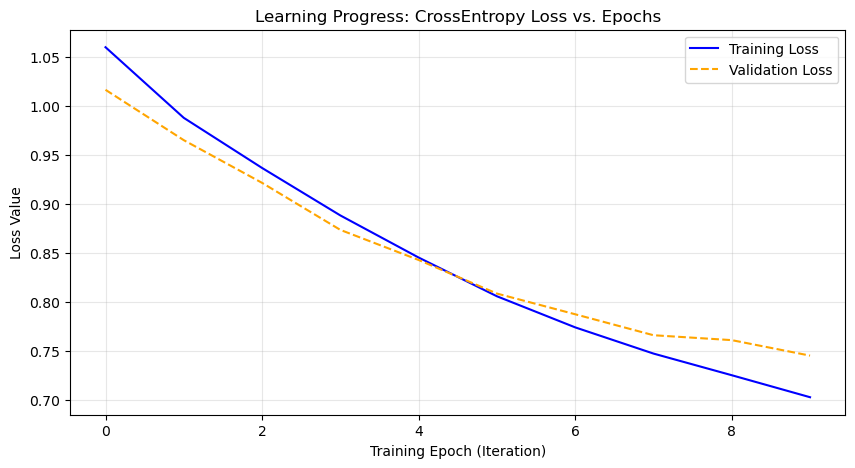

In [19]:
# --- LOSS CURVE VISUALIZATION ---
# Purpose: Evaluate convergence and check for overfitting.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
# Plotting the Training Loss (performance on the study set)
plt.plot(train_losses, label='Training Loss', color='blue', linestyle='-')

# Plotting the Validation Loss (performance on the unseen 'exam' set)
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')

# Adding context to the visualization
plt.title('Learning Progress: CrossEntropy Loss vs. Epochs')
plt.xlabel('Training Epoch (Iteration)')
plt.ylabel('Loss Value')
plt.grid(True, alpha=0.3) # Adds a subtle grid for easier value reading
plt.legend()
plt.show()

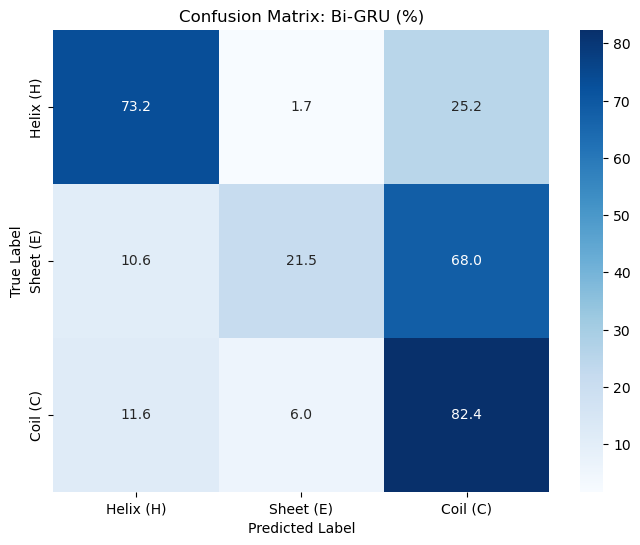


Raw Counts Matrix:
[[10831   245  3724]
 [  906  1839  5820]
 [ 2164  1117 15342]]


In [20]:
# --- EVALUATION: CONFUSION MATRIX GENERATION ---
# Purpose: To visualize inter-class confusion and identify which secondary 
# structures (H, E, or C) are most challenging for the model.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_optimized_confusion_matrix(model, loader):
    model.eval()
    all_true = []
    all_pred = []

    # 1. Collect all predictions from the validation set
    with torch.no_grad():
        for batch_pssm, batch_labels in loader:
            batch_pssm, batch_labels = batch_pssm.to(device), batch_labels.to(device)
            outputs = model(batch_pssm)
            _, preds = torch.max(outputs, dim=2)

            # Mask out padding (-1)
            mask = (batch_labels != -1)
            all_true.extend(batch_labels[mask].cpu().numpy())
            all_pred.extend(preds[mask].cpu().numpy())

    # 2. Calculate the matrix
    cm = confusion_matrix(all_true, all_pred)
    # Normalize by row (true class) to show percentages
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # 3. Plotting
    labels = ['Helix (H)', 'Sheet (E)', 'Coil (C)']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.title('Confusion Matrix: Bi-GRU (%)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Print the raw numbers too for your text report
    print("\nRaw Counts Matrix:")
    print(cm)

# Run the plot
plot_optimized_confusion_matrix(model, val_loader)

In [10]:
# --- OPTIMIZED ARCHITECTURE: DEEP BI-DIRECTIONAL GRU ---
# Improvements: Stacked layers for feature hierarchy and Dropout for regularization.

class OptimizedBiGRU(nn.Module):
    def __init__(self, input_size=20, hidden_size=128, output_size=3):
        super(OptimizedBiGRU, self).__init__()
        # RNN Configuration:
        # num_layers=2: Stacked architecture captures more abstract structural motifs.
        # dropout=0.3: Prevents overfitting between GRU layers.
        self.rnn = nn.GRU(input_size,
                          hidden_size,
                          num_layers=2,
                          batch_first=True,
                          bidirectional=True,
                          dropout=0.3)

        # Classification Head:
        # A multi-layer perception (MLP) head improves the decision boundary 
        # between structural classes (H, E, C).
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # Dimensionality reduction
            nn.ReLU(),                       # Non-linear activation
            nn.Dropout(0.2),                 # Regularization for the MLP
            nn.Linear(64, output_size)       # Final 3-class prediction
        )

    def forward(self, x):
        gru_out, _ = self.rnn(x)
        return self.classifier(gru_out)

In [ ]:
# --- SETUP ---
# 1. Setup Weights (H=1.2, E=1.5, C=0.8)
# We give E the most weight because it's usually the hardest to predict.
class_weights = torch.tensor([1.2, 1.5, 0.8]).to(device)

# 2. Define Criterion with weights and padding ignore
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)

# 3. Initialize Model and Optimizer
optimized_model = OptimizedBiGRU().to(device)
optimizer = torch.optim.Adam(optimized_model.parameters(), lr=0.001)

# This slows down the learning rate every 5 epochs to fine-tune the weights
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# --- OPTIMIZED TRAINING LOOP ---
train_losses, val_losses, val_q3_scores = [], [], []

print("Starting Optimized Training...")
for epoch in range(15):
    optimized_model.train()
    total_train_loss = 0
    for batch_pssm, batch_label in train_loader:
        batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)

        # Forward pass
        outputs = optimized_model(batch_pssm)
        loss = criterion(outputs.view(-1, 3), batch_label.view(-1))

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    scheduler.step()

    # --- VALIDATION ---
    optimized_model.eval()
    correct, total, total_val_loss = 0, 0, 0
    # Counters for Precision/Recall
    tp, fp, fn = [0, 0, 0], [0, 0, 0], [0, 0, 0]

    with torch.no_grad():
        for batch_pssm, batch_label in val_loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            out = optimized_model(batch_pssm)

            v_loss = criterion(out.view(-1, 3), batch_label.view(-1))
            total_val_loss += v_loss.item()

            _, pred = torch.max(out, dim=2)
            mask = (batch_label != -1)

            correct += ((pred == batch_label) & mask).sum().item()
            total += mask.sum().item()

            # Per-class metrics for H, E, C
            for c in [0, 1, 2]:
                tp[c] += ((pred == c) & (batch_label == c) & mask).sum().item()
                fp[c] += ((pred == c) & (batch_label != c) & mask).sum().item()
                fn[c] += ((pred != c) & (batch_label == c) & mask).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    current_q3 = (correct / total) * 100
    val_q3_scores.append(current_q3)

    # Calculate Precision and Recall
    precs = [tp[i] / (tp[i] + fp[i] + 1e-9) for i in range(3)]
    recs = [tp[i] / (tp[i] + fn[i] + 1e-9) for i in range(3)]
    avg_prec = sum(precs) / 3
    avg_rec = sum(recs) / 3

    print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {total_val_loss/len(val_loader):.4f} | Q3: {current_q3:.2f}%")
print(f"Metrics -> Q3: {val_q3_scores[-1]:.2f}% |  Precision: {avg_prec:.4f} | Recsll: {avg_rec:.4f}")

Starting Optimized Training...
Epoch 1: Train Loss 0.9778 | Val Loss 0.8538 | Q3: 54.71%
Epoch 2: Train Loss 0.8305 | Val Loss 0.7505 | Q3: 65.11%
Epoch 3: Train Loss 0.7320 | Val Loss 0.6732 | Q3: 68.60%
Epoch 4: Train Loss 0.6513 | Val Loss 0.6250 | Q3: 70.87%
Epoch 5: Train Loss 0.6089 | Val Loss 0.6009 | Q3: 74.32%
Epoch 6: Train Loss 0.5563 | Val Loss 0.5912 | Q3: 74.10%
Epoch 7: Train Loss 0.5454 | Val Loss 0.5906 | Q3: 74.39%
Epoch 8: Train Loss 0.5426 | Val Loss 0.5857 | Q3: 74.46%
Epoch 9: Train Loss 0.5357 | Val Loss 0.5857 | Q3: 74.16%
Epoch 10: Train Loss 0.5289 | Val Loss 0.5858 | Q3: 74.27%
Epoch 11: Train Loss 0.5243 | Val Loss 0.5836 | Q3: 74.61%
Epoch 12: Train Loss 0.5236 | Val Loss 0.5836 | Q3: 74.65%
Epoch 13: Train Loss 0.5235 | Val Loss 0.5836 | Q3: 74.74%
Epoch 14: Train Loss 0.5219 | Val Loss 0.5835 | Q3: 74.66%
Epoch 15: Train Loss 0.5223 | Val Loss 0.5837 | Q3: 74.64%
Metrics -> Q3: 74.64% |  Precision: 0.7299 | Recsll: 0.7489


In [12]:
# --- OPTIMIZED INFERENCE & VISUALIZATION ---
int_to_ss = {0: 'H', 1: 'E', 2: 'C'}

# Use the optimized model
optimized_model.eval() 
with torch.no_grad():
    # Grab the first protein from your validation subset
    test_pssm, test_seq, test_label = val_subset[0]
    input_tensor = test_pssm.unsqueeze(0).to(device) 

    # Prediction Pass
    output = optimized_model(input_tensor)
    _, predicted = torch.max(output, dim=2)
    
    # Clean up dimensions for string conversion
    pred_list = predicted.squeeze().tolist()
    true_list = test_label.tolist()

    # Decoding integers to SS letters
    true_str = "".join([int_to_ss[x] for x in true_list])
    pred_str = "".join([int_to_ss[x] for x in pred_list])
    compare = "".join(["|" if t == p else "." for t, p in zip(true_str, pred_str)])

    print(f"Results for Optimized Bi-GRU:")
    print(f"ID: {all_files[0]}")
    print(f"True:  {true_str[:80]}...") 
    print(f"Pred:  {pred_str[:80]}...")
    print(f"Match: {compare[:80]}...")

Results for Optimized Bi-GRU:
ID: d1a12a_
True:  CCCCCCCCCCEEEEECCCCCCCCEEEECCEEEEEEEEEECCCCCEEEEEEEECCCCCEEEEEEE...
Pred:  CCCCCCCCCCCCEEEEEEECCEEEEEEEECCEEEEEEEEECCCEEEEEEEEEEECCCEEEEEEE...
Match: ||||||||||..|||....||..||||....||||||||.|||.||||||||..||||||||||...


In [ ]:
# Detailed Evaluation: Computes residue-level classification metrics (Precision, Recall, F1-score)
# for each secondary structure class (H, E, C) across the validation set, ignoring padded positions.
from sklearn.metrics import classification_report

def get_optimized_metrics(loader, model):
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for batch_pssm, batch_label in loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            outputs = model(batch_pssm)
            _, predicted = torch.max(outputs, dim=2)

            mask = (batch_label != -1) # Filter out padding
            all_preds.extend(predicted[mask].cpu().numpy())
            all_true.extend(batch_label[mask].cpu().numpy())

    print("\n--- FINAL PERFORMANCE REPORT (Optimized Model) ---")
    print(classification_report(all_true, all_preds, target_names=['H', 'E', 'C']))

# Run the report on the validation set
get_optimized_metrics(val_loader, optimized_model)


--- FINAL PERFORMANCE REPORT (Optimized Model) ---
              precision    recall  f1-score   support

           H       0.78      0.85      0.81     13518
           E       0.61      0.72      0.66      7859
           C       0.80      0.67      0.73     16931

    accuracy                           0.75     38308
   macro avg       0.73      0.75      0.74     38308
weighted avg       0.76      0.75      0.75     38308



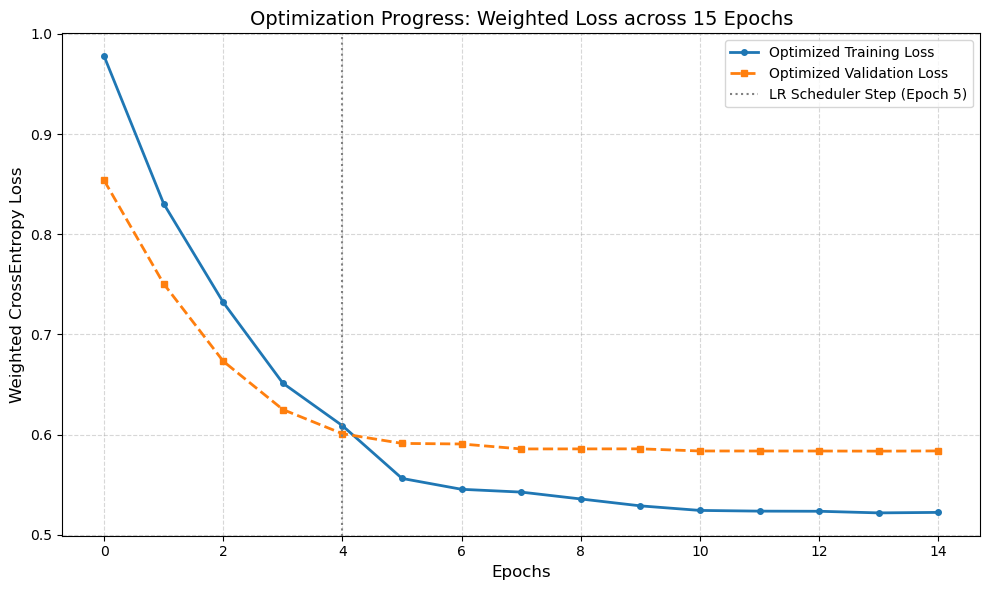

In [ ]:
# --- LOSS CURVE VISUALIZATION ---
# Purpose: Evaluate convergence and check for overfitting.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting with distinct markers to see the 15 epochs clearly
plt.plot(train_losses, label='Optimized Training Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(val_losses, label='Optimized Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--', marker='s', markersize=4)

# Highlighting the LR Scheduler Step
plt.axvline(x=4, color='gray', linestyle=':', label='LR Scheduler Step (Epoch 5)')

plt.title('Optimization Progress: Weighted Loss across 15 Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Weighted CrossEntropy Loss', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

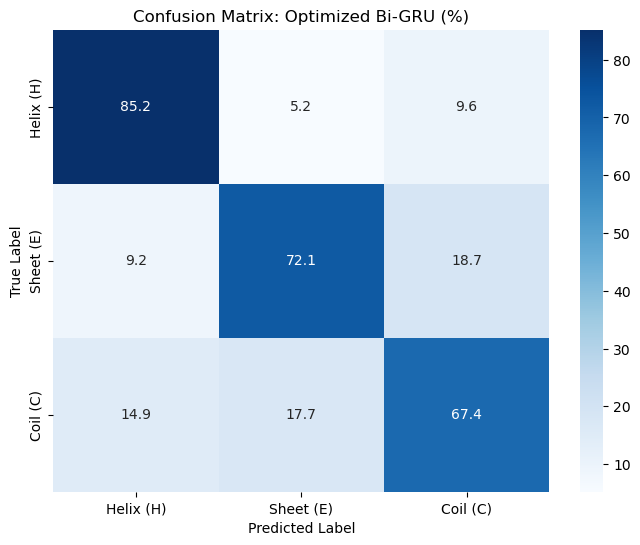


Raw Counts Matrix:
[[11517   704  1297]
 [  724  5665  1470]
 [ 2526  2994 11411]]


In [15]:
# --- EVALUATION: CONFUSION MATRIX GENERATION ---
# Purpose: To visualize inter-class confusion and identify which secondary 
# structures (H, E, or C) are most challenging for the model.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_optimized_confusion_matrix(model, loader):
    model.eval()
    all_true = []
    all_pred = []

    # 1. Collect all predictions from the validation set
    with torch.no_grad():
        for batch_pssm, batch_labels in loader:
            batch_pssm, batch_labels = batch_pssm.to(device), batch_labels.to(device)
            outputs = model(batch_pssm)
            _, preds = torch.max(outputs, dim=2)

            # Mask out padding (-1)
            mask = (batch_labels != -1)
            all_true.extend(batch_labels[mask].cpu().numpy())
            all_pred.extend(preds[mask].cpu().numpy())

    # 2. Calculate the matrix
    cm = confusion_matrix(all_true, all_pred)
    # Normalize by row (true class) to show percentages
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # 3. Plotting
    labels = ['Helix (H)', 'Sheet (E)', 'Coil (C)']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.title('Confusion Matrix: Optimized Bi-GRU (%)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Print the raw numbers too for your text report
    print("\nRaw Counts Matrix:")
    print(cm)

# Run the plot
plot_optimized_confusion_matrix(optimized_model, val_loader)

In [55]:
# --- ABLATION MODEL: ARCHITECTURAL DEPTH TEST ---
class AblationModel(nn.Module):
    def __init__(self, input_size=20, hidden_size=128, output_size=3, num_layers=1):
        super(AblationModel, self).__init__()
        
        # Bi-GRU Core:
        # Higher num_layers allows the model to learn hierarchical features 
        # (e.g., Layer 1 learns local motifs, Layer 2 learns global folds).
        self.rnn = nn.GRU(
            input_size, 
            hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0 # Dropout only works if layers > 1
        )

        # Classification Head:
        # Keeps the final decision logic constant across all layer tests
        # to ensure the ablation only measures the impact of the RNN depth.
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        gru_out, _ = self.rnn(x)
        return self.classifier(gru_out)

In [56]:
# --- ABLATION STUDY: IMPACT OF MODEL DEPTH ---
# I have varied the number of stacked Bi-GRU layers to find the optimal balance 
# between model capacity (power) and generalization (avoiding overfitting).
layer_results = {}

# Testing 1, 2, and 3 layers
for layers in [1, 2, 3]:
    print(f"\n🚀 STARTING ABLATION: {layers} Layer(s)")
    
    # 1. Initialize fresh model, optimizer, and criterion for THIS depth
    model = AblationModel(num_layers=layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    best_q3_this_run = 0
    
    for epoch in range(10):
        # --- Training ---
        model.train()
        for batch_pssm, batch_label in train_loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            outputs = model(batch_pssm)
            loss = criterion(outputs.view(-1, 3), batch_label.view(-1))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # --- Validation ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch_pssm, batch_label in val_loader:
                batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
                out = model(batch_pssm)
                _, pred = torch.max(out, dim=2)
                mask = (batch_label != -1)
                correct += ((pred == batch_label) & mask).sum().item()
                total += mask.sum().item()
        
        current_acc = (correct / total) * 100
        if current_acc > best_q3_this_run:
            best_q3_this_run = current_acc
            
        print(f"Epoch {epoch+1}: Q3 = {current_acc:.2f}%")
            
    layer_results[layers] = best_q3_this_run
    print(f"🏁 FINISHED: Best Q3 for {layers} layers: {best_q3_this_run:.2f}%")


🚀 STARTING ABLATION: 1 Layer(s)
Epoch 1: Q3 = 55.06%
Epoch 2: Q3 = 60.12%
Epoch 3: Q3 = 63.89%
Epoch 4: Q3 = 65.59%
Epoch 5: Q3 = 66.94%
Epoch 6: Q3 = 68.40%
Epoch 7: Q3 = 69.46%
Epoch 8: Q3 = 71.80%
Epoch 9: Q3 = 72.22%
Epoch 10: Q3 = 72.21%
🏁 FINISHED: Best Q3 for 1 layers: 72.22%

🚀 STARTING ABLATION: 2 Layer(s)
Epoch 1: Q3 = 60.77%
Epoch 2: Q3 = 66.16%
Epoch 3: Q3 = 69.88%
Epoch 4: Q3 = 72.47%
Epoch 5: Q3 = 73.36%
Epoch 6: Q3 = 74.60%
Epoch 7: Q3 = 75.05%
Epoch 8: Q3 = 74.57%
Epoch 9: Q3 = 75.61%
Epoch 10: Q3 = 74.43%
🏁 FINISHED: Best Q3 for 2 layers: 75.61%

🚀 STARTING ABLATION: 3 Layer(s)
Epoch 1: Q3 = 63.27%
Epoch 2: Q3 = 68.71%
Epoch 3: Q3 = 72.10%
Epoch 4: Q3 = 73.96%
Epoch 5: Q3 = 74.34%
Epoch 6: Q3 = 75.65%
Epoch 7: Q3 = 75.36%
Epoch 8: Q3 = 75.87%
Epoch 9: Q3 = 76.11%
Epoch 10: Q3 = 76.29%
🏁 FINISHED: Best Q3 for 3 layers: 76.29%


In [57]:
# --- ABLATION STUDY: LEARNING RATE SENSITIVITY ---
# Purpose: To find the optimal step size that allows the model to 
# descend the loss landscape without oscillating or stalling.
lr_results = {}

# Testing Aggressive, Standard, and Conservative rates
for lr_val in [0.01, 0.001, 0.0001]:
    print(f"\n🚀 STARTING ABLATION: Learning Rate = {lr_val}")
    
    # We fix num_layers=2 so we only change the LR
    model = AblationModel(num_layers=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_val)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    best_q3_this_run = 0
    
    for epoch in range(10):
        model.train()
        for batch_pssm, batch_label in train_loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            outputs = model(batch_pssm)
            loss = criterion(outputs.view(-1, 3), batch_label.view(-1))
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch_pssm, batch_label in val_loader:
                batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
                out = model(batch_pssm)
                _, pred = torch.max(out, dim=2)
                mask = (batch_label != -1)
                correct += ((pred == batch_label) & mask).sum().item()
                total += mask.sum().item()
        
        current_acc = (correct / total) * 100
        if current_acc > best_q3_this_run:
            best_q3_this_run = current_acc
            
        print(f"Epoch {epoch+1}: Q3 = {current_acc:.2f}%")
            
    lr_results[lr_val] = best_q3_this_run
    print(f"🏁 FINISHED: Best Q3 for LR {lr_val}: {best_q3_this_run:.2f}%")


🚀 STARTING ABLATION: Learning Rate = 0.01
Epoch 1: Q3 = 61.10%
Epoch 2: Q3 = 64.92%
Epoch 3: Q3 = 69.69%
Epoch 4: Q3 = 71.20%
Epoch 5: Q3 = 72.96%
Epoch 6: Q3 = 71.79%
Epoch 7: Q3 = 74.20%
Epoch 8: Q3 = 74.33%
Epoch 9: Q3 = 69.54%
Epoch 10: Q3 = 69.41%
🏁 FINISHED: Best Q3 for LR 0.01: 74.33%

🚀 STARTING ABLATION: Learning Rate = 0.001
Epoch 1: Q3 = 59.93%
Epoch 2: Q3 = 66.70%
Epoch 3: Q3 = 70.73%
Epoch 4: Q3 = 70.84%
Epoch 5: Q3 = 74.33%
Epoch 6: Q3 = 74.73%
Epoch 7: Q3 = 74.76%
Epoch 8: Q3 = 75.16%
Epoch 9: Q3 = 74.96%
Epoch 10: Q3 = 75.16%
🏁 FINISHED: Best Q3 for LR 0.001: 75.16%

🚀 STARTING ABLATION: Learning Rate = 0.0001
Epoch 1: Q3 = 47.70%
Epoch 2: Q3 = 53.00%
Epoch 3: Q3 = 57.53%
Epoch 4: Q3 = 60.26%
Epoch 5: Q3 = 61.74%
Epoch 6: Q3 = 62.58%
Epoch 7: Q3 = 63.85%
Epoch 8: Q3 = 64.47%
Epoch 9: Q3 = 65.68%
Epoch 10: Q3 = 66.63%
🏁 FINISHED: Best Q3 for LR 0.0001: 66.63%


In [ ]:
# --- ABLATION STUDY: HIDDEN LAYER DIMENSIONALITY (WIDTH) ---
# Purpose: Determining the optimal 'capacity' of the model. 
# Too small = Underfitting (can't learn complexity).
# Too large = Overfitting (memorizes training data, fails on validation).
hidden_results = {}

for size in [32, 128, 512]:
    print(f"\n🚀 STARTING ABLATION: Hidden Size = {size}")
    
    # Initialize with varying hidden_size
    model = AblationModel(num_layers=2, hidden_size=size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    best_q3_this_run = 0
    
    for epoch in range(10):
        model.train()
        for batch_pssm, batch_label in train_loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            outputs = model(batch_pssm)
            loss = criterion(outputs.view(-1, 3), batch_label.view(-1))
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch_pssm, batch_label in val_loader:
                batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
                out = model(batch_pssm)
                _, pred = torch.max(out, dim=2)
                mask = (batch_label != -1)
                correct += ((pred == batch_label) & mask).sum().item()
                total += mask.sum().item()
        
        current_acc = (correct / total) * 100
        if current_acc > best_q3_this_run:
            best_q3_this_run = current_acc
            
        print(f"Epoch {epoch+1}: Q3 = {current_acc:.2f}%")
            
    hidden_results[size] = best_q3_this_run
    print(f"🏁 FINISHED: Best Q3 for Hidden Size {size}: {best_q3_this_run:.2f}%")


🚀 STARTING ABLATION: Hidden Size = 32
Epoch 1: Q3 = 51.51%
Epoch 2: Q3 = 58.30%
Epoch 3: Q3 = 60.79%
Epoch 4: Q3 = 62.02%
Epoch 5: Q3 = 63.63%
Epoch 6: Q3 = 65.82%
Epoch 7: Q3 = 66.67%
Epoch 8: Q3 = 68.06%
Epoch 9: Q3 = 69.00%
Epoch 10: Q3 = 68.74%
🏁 FINISHED: Best Q3 for Hidden Size 32: 69.00%

🚀 STARTING ABLATION: Hidden Size = 128
Epoch 1: Q3 = 57.66%
Epoch 2: Q3 = 65.45%
Epoch 3: Q3 = 68.82%
Epoch 4: Q3 = 72.09%
Epoch 5: Q3 = 74.53%
Epoch 6: Q3 = 75.36%
Epoch 7: Q3 = 76.25%
Epoch 8: Q3 = 76.41%
Epoch 9: Q3 = 76.12%
Epoch 10: Q3 = 76.53%
🏁 FINISHED: Best Q3 for Hidden Size 128: 76.53%

🚀 STARTING ABLATION: Hidden Size = 512
Epoch 1: Q3 = 64.18%
Epoch 2: Q3 = 70.00%
Epoch 3: Q3 = 75.14%
Epoch 4: Q3 = 75.91%
Epoch 5: Q3 = 75.64%
Epoch 6: Q3 = 76.77%
Epoch 7: Q3 = 76.44%
Epoch 8: Q3 = 76.23%
Epoch 9: Q3 = 76.47%
Epoch 10: Q3 = 75.98%
🏁 FINISHED: Best Q3 for Hidden Size 512: 76.77%


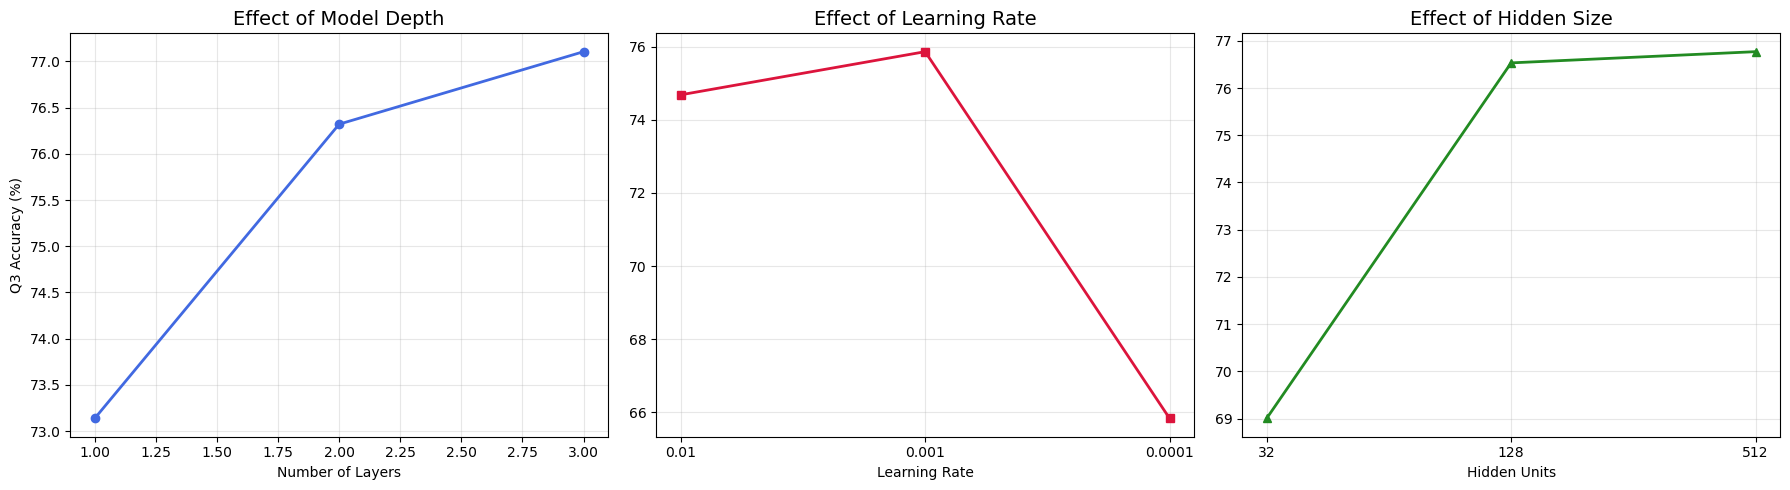

In [ ]:
# --- ABLATION ANALYSIS: HYPERPARAMETER SENSITIVITY ---
# Purpose: This visualization identifies the how the changes in number of layers,
# learning rate and hidden layer size affects model's performance. 

import matplotlib.pyplot as plt

# Prepare Data
layer_x, layer_y = list(layer_results.keys()), list(layer_results.values())
lr_x, lr_y = [str(val) for val in lr_results.keys()], list(lr_results.values())
hidden_x, hidden_y = [str(val) for val in hidden_results.keys()], list(hidden_results.values())

# Create the Figure
plt.figure(figsize=(18, 5))

# Plot 1: Layers
plt.subplot(1, 3, 1)
plt.plot(layer_x, layer_y, marker='o', color='royalblue', linewidth=2)
plt.title('Effect of Model Depth', fontsize=14)
plt.xlabel('Number of Layers')
plt.ylabel('Q3 Accuracy (%)')
plt.grid(True, alpha=0.3)

# Plot 2: Learning Rate
plt.subplot(1, 3, 2)
plt.plot(lr_x, lr_y, marker='s', color='crimson', linewidth=2)
plt.title('Effect of Learning Rate', fontsize=14)
plt.xlabel('Learning Rate')
plt.grid(True, alpha=0.3)

# Plot 3: Hidden Size
plt.subplot(1, 3, 3)
plt.plot(hidden_x, hidden_y, marker='^', color='forestgreen', linewidth=2)
plt.title('Effect of Hidden Size', fontsize=14)
plt.xlabel('Hidden Units')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
#Ablation for the number of epochs used to train the normal Bi-GRU model
#Here I increased epochs to 20. 

#Creating the training loop 
import torch.optim as optim

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ProteinModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
val_q3_scores = []

# Training for 'n' epochs: Before the presentation, I conducted only 10 epochs. After my presentation, I decided to train it to 20 epochs as well. 
# The results for 20 epochs is included as an ablation study at the end. 
for epoch in range(20):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    for batch_pssm, batch_label in train_loader:
        batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
        
        # FORWARD PASS: Generate raw prediction scores (logits).
        outputs = model(batch_pssm)
        # Flatten the 3D data (Batch, Seq, Class)to [Total_Residues, 3] to match CrossEntropyLoss requirements.
        loss = criterion(outputs.view(-1, 3), batch_label.view(-1))

        # BACKPROPAGATION: Update weights using the Adam optimizer based on the loss gradient.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    # Initialize counters for H(0), E(1), C(2)
    tp = [0, 0, 0]
    fp = [0, 0, 0]
    fn = [0, 0, 0]
    total_correct = 0
    total_residues = 0
    correct, total = 0, 0
    with torch.no_grad(): #disable the gradient computation during testing 
        for batch_pssm, batch_label in val_loader:
            batch_pssm, batch_label = batch_pssm.to(device), batch_label.to(device)
            outputs = model(batch_pssm)

            # Loss
            loss = criterion(outputs.view(-1, 3), batch_label.view(-1))
            total_val_loss += loss.item()

            # Q3 CALCULATION: Accuracy over the 3 structural states, excluding padding (-1).
            _, predicted = torch.max(outputs, dim=2) # Find the class with the highest score
            mask = (batch_label != -1)               # Identify real residues (not padding)
            correct += ((predicted == batch_label) & mask).sum().item()
            total += mask.sum().item()

            # Manual Metric Logic
            for c in [0, 1, 2]: # For each class H, E, C
                tp[c] += ((predicted == c) & (batch_label == c) & mask).sum().item()
                fp[c] += ((predicted == c) & (batch_label != c) & mask).sum().item()
                fn[c] += ((predicted != c) & (batch_label == c) & mask).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_q3_scores.append((correct / total) * 100)

    precisions = [tp[i] / (tp[i] + fp[i] + 1e-9) for i in range(3)]
    recalls = [tp[i] / (tp[i] + fn[i] + 1e-9) for i in range(3)]
    
    macro_precision = sum(precisions) / 3
    macro_recall = sum(recalls) / 3

    print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Q3 {val_q3_scores[-1]:.2f}%")
print(f"Metrics -> Q3: {val_q3_scores[-1]:.2f}% | Precision: {macro_precision:.4f} | Recall: {macro_recall:.4f}")
    

Epoch 1: Train Loss 1.0630 | Val Loss 1.0269 | Q3 47.23%
Epoch 2: Train Loss 0.9961 | Val Loss 0.9734 | Q3 52.56%
Epoch 3: Train Loss 0.9337 | Val Loss 0.9118 | Q3 56.34%
Epoch 4: Train Loss 0.8783 | Val Loss 0.8727 | Q3 59.17%
Epoch 5: Train Loss 0.8422 | Val Loss 0.8345 | Q3 61.37%
Epoch 6: Train Loss 0.8037 | Val Loss 0.8101 | Q3 63.08%
Epoch 7: Train Loss 0.7721 | Val Loss 0.7919 | Q3 64.35%
Epoch 8: Train Loss 0.7442 | Val Loss 0.7672 | Q3 65.47%
Epoch 9: Train Loss 0.7220 | Val Loss 0.7537 | Q3 66.30%
Epoch 10: Train Loss 0.6985 | Val Loss 0.7515 | Q3 66.31%
Epoch 11: Train Loss 0.6841 | Val Loss 0.7281 | Q3 68.16%
Epoch 12: Train Loss 0.6614 | Val Loss 0.7130 | Q3 68.79%
Epoch 13: Train Loss 0.6414 | Val Loss 0.7097 | Q3 69.41%
Epoch 14: Train Loss 0.6264 | Val Loss 0.7023 | Q3 69.82%
Epoch 15: Train Loss 0.6133 | Val Loss 0.6954 | Q3 70.17%
Epoch 16: Train Loss 0.5994 | Val Loss 0.6904 | Q3 70.60%
Epoch 17: Train Loss 0.5858 | Val Loss 0.6798 | Q3 71.18%
Epoch 18: Train Loss 0.

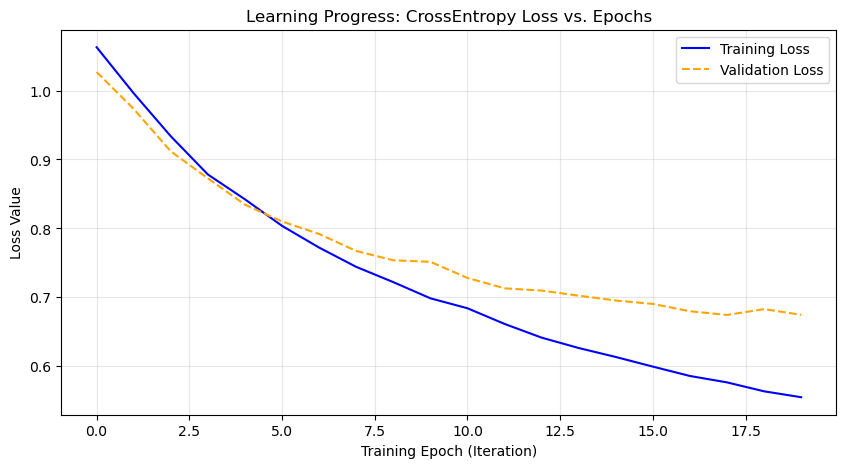

In [28]:
# --- LOSS CURVE VISUALIZATION ---
# Purpose: Evaluate convergence and check for overfitting.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
# Plotting the Training Loss (performance on the study set)
plt.plot(train_losses, label='Training Loss', color='blue', linestyle='-')

# Plotting the Validation Loss (performance on the unseen 'exam' set)
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')

# Adding context to the visualization
plt.title('Learning Progress: CrossEntropy Loss vs. Epochs')
plt.xlabel('Training Epoch (Iteration)')
plt.ylabel('Loss Value')
plt.grid(True, alpha=0.3) # Adds a subtle grid for easier value reading
plt.legend()
plt.show()